In [1]:
import numpy as np
from matplotlib import pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.linalg import eigh
from scipy import interpolate as interp
from mpmath import polylog

from datataking import search_datadict_miyamura
from scipy import interpolate
from analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

In [2]:
cd = "CDY164"
data_path = f"C:\\Users\\qipe\\qutip_simulation\\codes\\data\\{cd}"
readout_lo_freq = 9.47

In [3]:
name_dict = dict(
    # data1 = dict(amp=0.1, date="2024-08-12", acquire_time="003056", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data2 = dict(amp=0.2, date="2024-08-09", acquire_time="121615", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data3 = dict(amp=0.3, date="2024-08-12", acquire_time="005041", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data4 = dict(amp=0.4, date="2024-08-09", acquire_time="124243", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data5 = dict(amp=0.5, date="2024-08-12", acquire_time="005802", params=dict(fit_start=42, fp=0.03, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data55 = dict(amp=0.55, date="2024-08-09", acquire_time="130752", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.6, date="2024-08-12", acquire_time="010340", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data7 = dict(amp=0.7, date="2024-08-12", acquire_time="010919", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data75 = dict(amp=0.75, date="2024-08-12", acquire_time="011458", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data8 = dict(amp=0.8, date="2024-08-12", acquire_time="012033", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data85 = dict(amp=0.85, date="2024-08-12", acquire_time="012618", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data9 = dict(amp=0.9, date="2024-08-12", acquire_time="013204", params=dict(fit_start=42, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data10 = dict(amp=1.0, date="2024-08-09", acquire_time="051414", params=dict(fit_start=80, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

In [4]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
fitted_waveforms = dataobj.generate_results(readout_lo_freq)

0.3 2024-08-12 005041
0.5 2024-08-12 005802
0.6 2024-08-12 010340
0.7 2024-08-12 010919
0.75 2024-08-12 011458
0.85 2024-08-12 012618


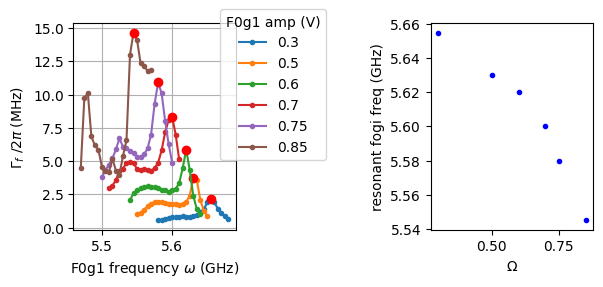

In [5]:
# form = "sech_0"
# const = 2.5e-3 * 2 * np.pi
# duration = 1000
# target_freq = 9.35

# plot decay rates
fogi_amps, max_decay_freq, fogi_freqs, decay_rates = dataobj.plot_decayrates()
resonant_fogi_freq = np.array(max_decay_freq) * 1e9

<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\G'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\3282221874.py:10: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\3282221874.py:11: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')


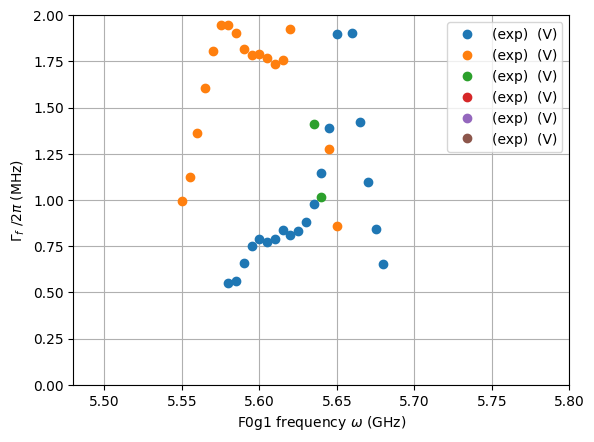

In [6]:
import matplotlib.cm as cm
# cmap = cm.get_cmap("tab10", len(Omegas))

for i in range(len(fogi_freqs)):
    # color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp)  (V)")
    # plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega[i]) * 2,
    #           '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    plt.legend()
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.8)
plt.ylim(0, 2)
plt.grid()

<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\51486952.py:2: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('fogi amplitude $\Omega$')


Text(0, 0.5, 'resonant fogi freq (GHz)')

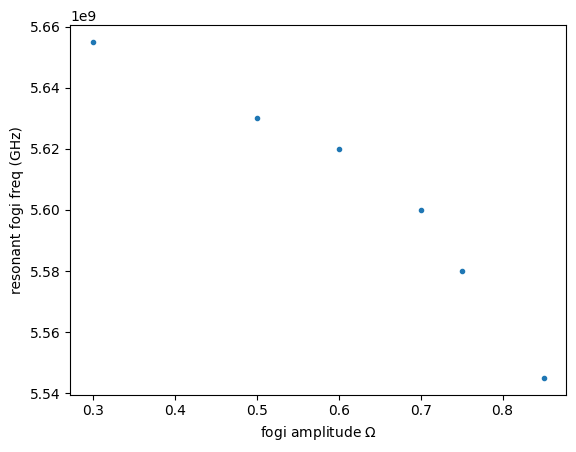

In [7]:
plt.plot(fogi_amps, resonant_fogi_freq, '.')
plt.xlabel('fogi amplitude $\Omega$')
plt.ylabel('resonant fogi freq (GHz)')

Fitted c: 7019359148.957378
Fitted omega_fg: 5678491677.382938
-242000252490663.38


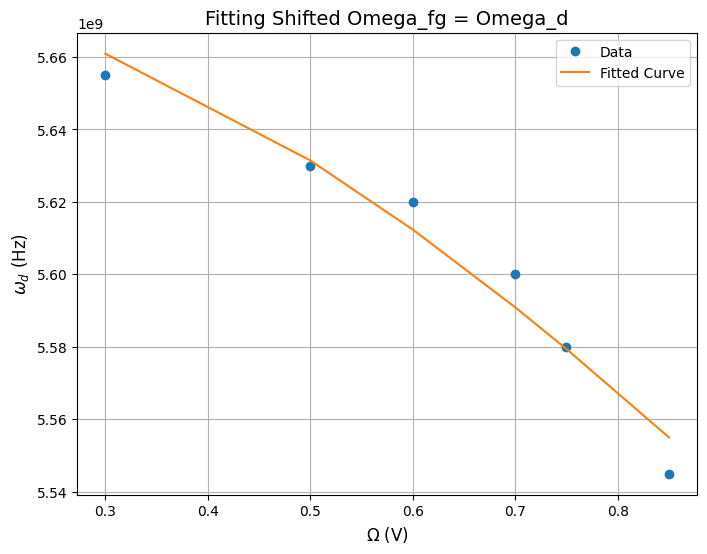

In [8]:
from scipy.optimize import fsolve
from scipy.optimize import curve_fit

omega_q = 7.699e9 * 2 * np.pi
alpha = -0.372e9 * 2 * np.pi

def shifted_omega_fg_fit(Omega, c, omega_fg):
    def calc_omega_d(Omega, c, omega_fg):
        def equation(omega_d):
            delta_qd = omega_q - omega_d
            numer = alpha * (2 * delta_qd + alpha) * (c * Omega)**2
            denom = 2 * delta_qd * (delta_qd + alpha) * (delta_qd + 2 * alpha)
            return omega_fg + numer / denom - omega_d

        omega_d_initial_guess = omega_fg
        return fsolve(equation, omega_d_initial_guess)[0]

    return np.array([calc_omega_d(om, c, omega_fg) for om in Omega])


initial_guess = [7.5e9, 5.67e9*2*np.pi]
popt, pcov = curve_fit(
    lambda Omega, c, omega_fg: shifted_omega_fg_fit(Omega, c, omega_fg),
    fogi_amps,
    resonant_fogi_freq*2*np.pi,
    p0=initial_guess
)

fitted_c, fitted_omega_fg = popt
print(f"Fitted c: {fitted_c}")
print(f"Fitted omega_fg: {fitted_omega_fg/2/np.pi}")

print(alpha * (2 * (omega_q - resonant_fogi_freq[0]*2*np.pi) + alpha) * (fitted_c * fogi_amps[0])**2*(1e-6)**4)


initial_fitted_values = shifted_omega_fg_fit(fogi_amps, initial_guess[0], initial_guess[1])
fitted_omega_d_values = shifted_omega_fg_fit(fogi_amps, fitted_c, fitted_omega_fg)

plt.figure(figsize=(8, 6))
plt.plot(fogi_amps, resonant_fogi_freq, 'o', label="Data")
# plt.plot(fogi_amps, initial_fitted_values / (2 * np.pi), '--', label="Initial Fit") 
plt.plot(fogi_amps, fitted_omega_d_values/(2*np.pi), '-', label="Fitted Curve")
plt.xlabel(r"$\Omega$ (V)", fontsize=12)
plt.ylabel(r"$\omega_d$ (Hz)", fontsize=12)
plt.title("Fitting Shifted Omega_fg = Omega_d", fontsize=14)
plt.grid()
plt.legend()
plt.show()


qutip simulation

In [9]:
from qutip import *

In [10]:
Nqu=4;
Nres=3;
Nfil=3;
## define qubit 
omegaq=2*np.pi*7699;
aharmon=-2*np.pi*372;
chi=-2*np.pi*3.05;

bqub=destroy(Nqu);
bqubd=create(Nqu);


## define resonator
omegares=2*np.pi*9375;
delta=omegaq - omegares;
Jcavfil=2*np.pi*46;

cavobj=basis(Nres);
acav=destroy(Nres);
acavd=create(Nres);
## define filter
omegafil=2*np.pi*9391;
kappa=2*np.pi*95
filterobj=basis(Nfil);
fcav=destroy(Nfil);
fcavd=create(Nfil);

## qubit-resonator coupling strength
gqcav=(chi*delta*(delta+aharmon)/aharmon)**0.5-20*2*np.pi;

omega_rotate=0#2*np.pi*6000

In [11]:
zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)

zeromatrixxtmp=np.zeros([Nqu,Nqu])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)

T1geapprox=22
T1efapprox=12
T2geapprox=8
gammaT1ge=1/T1geapprox #
gammaT1ef=1/T1efapprox #
gammaTphige=(1/T2geapprox-1/T1geapprox/2)/2
##### 
c_ops_fil=[];
c_ops_fil.append(np.sqrt(kappa)*tensor(qeye(Nqu),qeye(Nres),fcav))
# c_ops_fil.append(np.sqrt(gammaT1ge)*tensor(gedecayop,qeye(Nres),qeye(Nfil)))
# c_ops_fil.append(np.sqrt(gammaT1ef)*tensor(efdecayop,qeye(Nres),qeye(Nfil)))
# c_ops_fil.append(np.sqrt(gammaTphige)*tensor(gedechoop,qeye(Nres),qeye(Nfil)))

In [12]:
H0_fil=(omegaq-omega_rotate)*tensor(bqubd*bqub,qeye(Nres),qeye(Nfil))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres),qeye(Nfil))\
+(omegares-omega_rotate)*tensor(qeye(Nqu),acavd*acav,qeye(Nfil))+gqcav*(tensor(bqub,acavd,qeye(Nfil))+tensor(bqubd,acav,qeye(Nfil)))\
+(omegafil-omega_rotate)*tensor(qeye(Nqu),qeye(Nres),fcavd*fcav)+Jcavfil*(tensor(qeye(Nqu),acavd,fcav)+tensor(qeye(Nqu),acav,fcavd))

def H1_coeff_sq_f0g1_pulse_ani(t, args):
    return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(-1j*omega_rotate*t)

def H1_coeff_sq_f0g1_pulse_crea(t, args):
    return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(1j*omega_rotate*t)

H1_anni_fil= tensor(bqub,qeye(Nres),qeye(Nfil))
H1_crea_fil= tensor(bqubd,qeye(Nres),qeye(Nfil))

H_f0g1_fil = [ H0_fil,
              [H1_anni_fil, H1_coeff_sq_f0g1_pulse_ani],
              [H1_crea_fil, H1_coeff_sq_f0g1_pulse_crea]
            ]

In [13]:
eigsystem_fil=H0_fil.eigenstates()
f0_fil=tensor(basis(Nqu,2),cavobj,filterobj);
e0_fil=tensor(basis(Nqu,1),cavobj,filterobj);
g0_fil=tensor(basis(Nqu),cavobj,filterobj);

overlaplistf0_fil=[fidelity(f0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlapliste0_fil=[fidelity(e0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
overlaplistg0_fil=[fidelity(g0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]

maxindexf0_fil=overlaplistf0_fil.index(max(overlaplistf0_fil))
maxindexe0_fil=overlapliste0_fil.index(max(overlapliste0_fil))
maxindexg0_fil=overlaplistg0_fil.index(max(overlaplistg0_fil))

initialstatef0_fil=eigsystem_fil[1][maxindexf0_fil]
initialstatee0_fil=eigsystem_fil[1][maxindexe0_fil]
initialstateg0_fil=g0_fil

In [14]:
Tf=0.8
t=np.linspace(0,Tf, 401)
testinitialstate_fil=(initialstatef0_fil+initialstateg0_fil).unit()

In [47]:

gstate_fil=tensor(ket2dm(basis(Nqu)),qeye(Nres),qeye(Nfil))
estate_fil=tensor(ket2dm(basis(Nqu,1)),qeye(Nres),qeye(Nfil))
fstate_fil=tensor(ket2dm(basis(Nqu,2)),qeye(Nres),qeye(Nfil))
hstate_fil=tensor(ket2dm(basis(Nqu,3)),qeye(Nres),qeye(Nfil))

omegadrive_f0g1_dict = {
    # 0.3: np.array(np.linspace(5.58, 5.68, 11)) *1e3* 2 * np.pi,
    # 0.5: np.array(np.linspace(5.55, 5.65, 11))*1e3*  2 * np.pi,
    # 0.6: np.array(np.linspace(5.54, 5.64, 11))*1e3*  2 * np.pi,
    0.7: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi,
    # 0.75: np.array(np.linspace(5.5, 5.6, 11))*1e3*  2 * np.pi,
    # 0.85: np.array(np.linspace(5.48, 5.58, 11))*1e3*  2 * np.pi,
}
# Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
Omegas = np.array([0.7])

results2 = []
for Omega in Omegas:
    output_decay_f0g1_fils = []
    drive_freqs = omegadrive_f0g1_dict[Omega]  
    for drive_freq in drive_freqs:
        args = {
            'Omegagf': fitted_c*1e-6*Omega,
            'omegadrive_f0g1': drive_freq
        }

        output_decay_f0g1_fil = mesolve(H_f0g1_fil,testinitialstate_fil, t, c_ops_fil,e_ops=[gstate_fil,estate_fil,fstate_fil,hstate_fil,tensor(qeye(Nqu),qeye(Nres),fcav)], args=args, progress_bar=True)
        output_decay_f0g1_fils.append(output_decay_f0g1_fil)
        print(f'Omegagf={Omega}, omegadrive_f0g1={drive_freq/(2*np.pi)} finished')
    results2.append(output_decay_f0g1_fils)

qutip.qsave(results2, "250116_0_worot_g-20")

10.0%. Run time:   8.44s. Est. time left: 00:00:01:15
20.0%. Run time:  17.46s. Est. time left: 00:00:01:09
30.0%. Run time:  26.76s. Est. time left: 00:00:01:02
40.0%. Run time:  35.69s. Est. time left: 00:00:00:53
50.0%. Run time:  44.71s. Est. time left: 00:00:00:44
60.0%. Run time:  53.91s. Est. time left: 00:00:00:35
70.0%. Run time:  62.86s. Est. time left: 00:00:00:26
80.0%. Run time:  72.27s. Est. time left: 00:00:00:18
90.0%. Run time:  81.16s. Est. time left: 00:00:00:09
100.0%. Run time:  89.35s. Est. time left: 00:00:00:00
Total run time:  89.35s
Omegagf=0.3, omegadrive_f0g1=5580.0 finished
10.0%. Run time:   8.36s. Est. time left: 00:00:01:15
20.0%. Run time:  16.72s. Est. time left: 00:00:01:06
30.0%. Run time:  25.02s. Est. time left: 00:00:00:58
40.0%. Run time:  33.37s. Est. time left: 00:00:00:50
50.0%. Run time:  41.58s. Est. time left: 00:00:00:41
60.0%. Run time:  49.96s. Est. time left: 00:00:00:33
70.0%. Run time:  58.22s. Est. time left: 00:00:00:24
80.0%. Run t

In [15]:
results2 = qload('250116_0_worot')
result_J = qload('250116_0_worot_J+50')
result_J20 = qload('250116_0_worot_J+20')
result_g20 = qload('250116_0_worot_g+20')
result_gmi20 = qload('250116_0_worot_g-20')
result_kappa20 = qload('250116_0_worot_kappa+20')

In [16]:
from analysis import decay
import lmfit as lmf

def guess_params_decay(data, t):
    off_ini = np.mean(data[-5:])#data[-1]
    moving_average = np.convolve(data, np.ones(25)/25, mode="valid")
    A_ini = moving_average[0]#np.sign(data[0]-data[-1])*(max(data) - min(data))
    par_ini = {
        'gamma': abs((moving_average[0]-moving_average[5])/(t[0]-t[5]))/A_ini,#-(data[0]-data[2])/(t[0]-t[2]) ,
        'A': A_ini,'off': off_ini
    }
    par_max = {'gamma': 1e3,'A': 2*A_ini,'off': 5*np.abs(off_ini)}
    par_min = {'gamma': 0,'A': 0.5*A_ini,'off': -5*np.abs(off_ini)}
    par_vary = {'gamma': True,'A': True,'off': True,}
    return par_ini,par_max,par_min,par_vary

def decay_fit(data, t):
    decay_model = lmf.Model(decay)
    params_decay = decay_model.make_params()
    decay_par_ini,decay_par_max,decay_par_min,decay_par_vary=guess_params_decay(data,t)
    for name in params_decay:
        params_decay[name].set(
            value=decay_par_ini[name],  # 初期値
            min=decay_par_min[name],  # 下限値
            max=decay_par_max[name],  # 上限値
            vary=decay_par_vary[name] # パラメータを動かすかどうか
        )
    result=decay_model.fit(data, t=t, params=params_decay, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    return result

In [50]:
skip_data = 15
fits_by_omega = []
tmfs_by_omega = []
tmf_times_by_omega = []
decay_rates_by_omega = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(results2):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        # ax.plot(t, tmf, label=f"Omega_idx={omega_idx}, Detun_idx={detun_idx}")
        # ax.plot(t[skip_data:], fit_result.best_fit, label="Fit")
        # ax.set_title(f"Omega={Omegas[omega_idx]:.1f}, omega_d={omegadrive_f0g1_dict[Omegas[omega_idx]][detun_idx]/(2*np.pi):.1f} MHz")
        # ax.set_xlabel("Time")
        # ax.set_ylabel("Amplitude")
        # ax.legend()
        # ax.grid()

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega.append(fits_per_omega)
    tmfs_by_omega.append(tmfs_per_omega)
    tmf_times_by_omega.append(tmf_times_per_omega)
    decay_rates_by_omega.append(decay_rates_per_omega)

In [17]:
skip_data = 15
fits_by_omega = []
tmfs_by_omega = []
tmf_times_by_omega = []
decay_rates_by_omega = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_J20):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega.append(fits_per_omega)
    tmfs_by_omega.append(tmfs_per_omega)
    tmf_times_by_omega.append(tmf_times_per_omega)
    decay_rates_by_omega.append(decay_rates_per_omega)

<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\o'
C:\Users\qipe\AppData\Local\Temp\ipykernel_24460\2800129551.py:31: SyntaxWarning: invalid escape sequence '\O'
  ax.set_title(f"$\Omega$={Omegas[amp_idx]:.2f}, "
C:\Users\qipe\AppData\Local\Temp\ipykernel_24460\2800129551.py:32: SyntaxWarning: invalid escape sequence '\o'
  f"$\omega_d$={omegadrive_f0g1_dict[Omegas[amp_idx]][idx]/(2*np.pi):.1f} MHz")


IndexError: index 11 is out of bounds for axis 0 with size 11

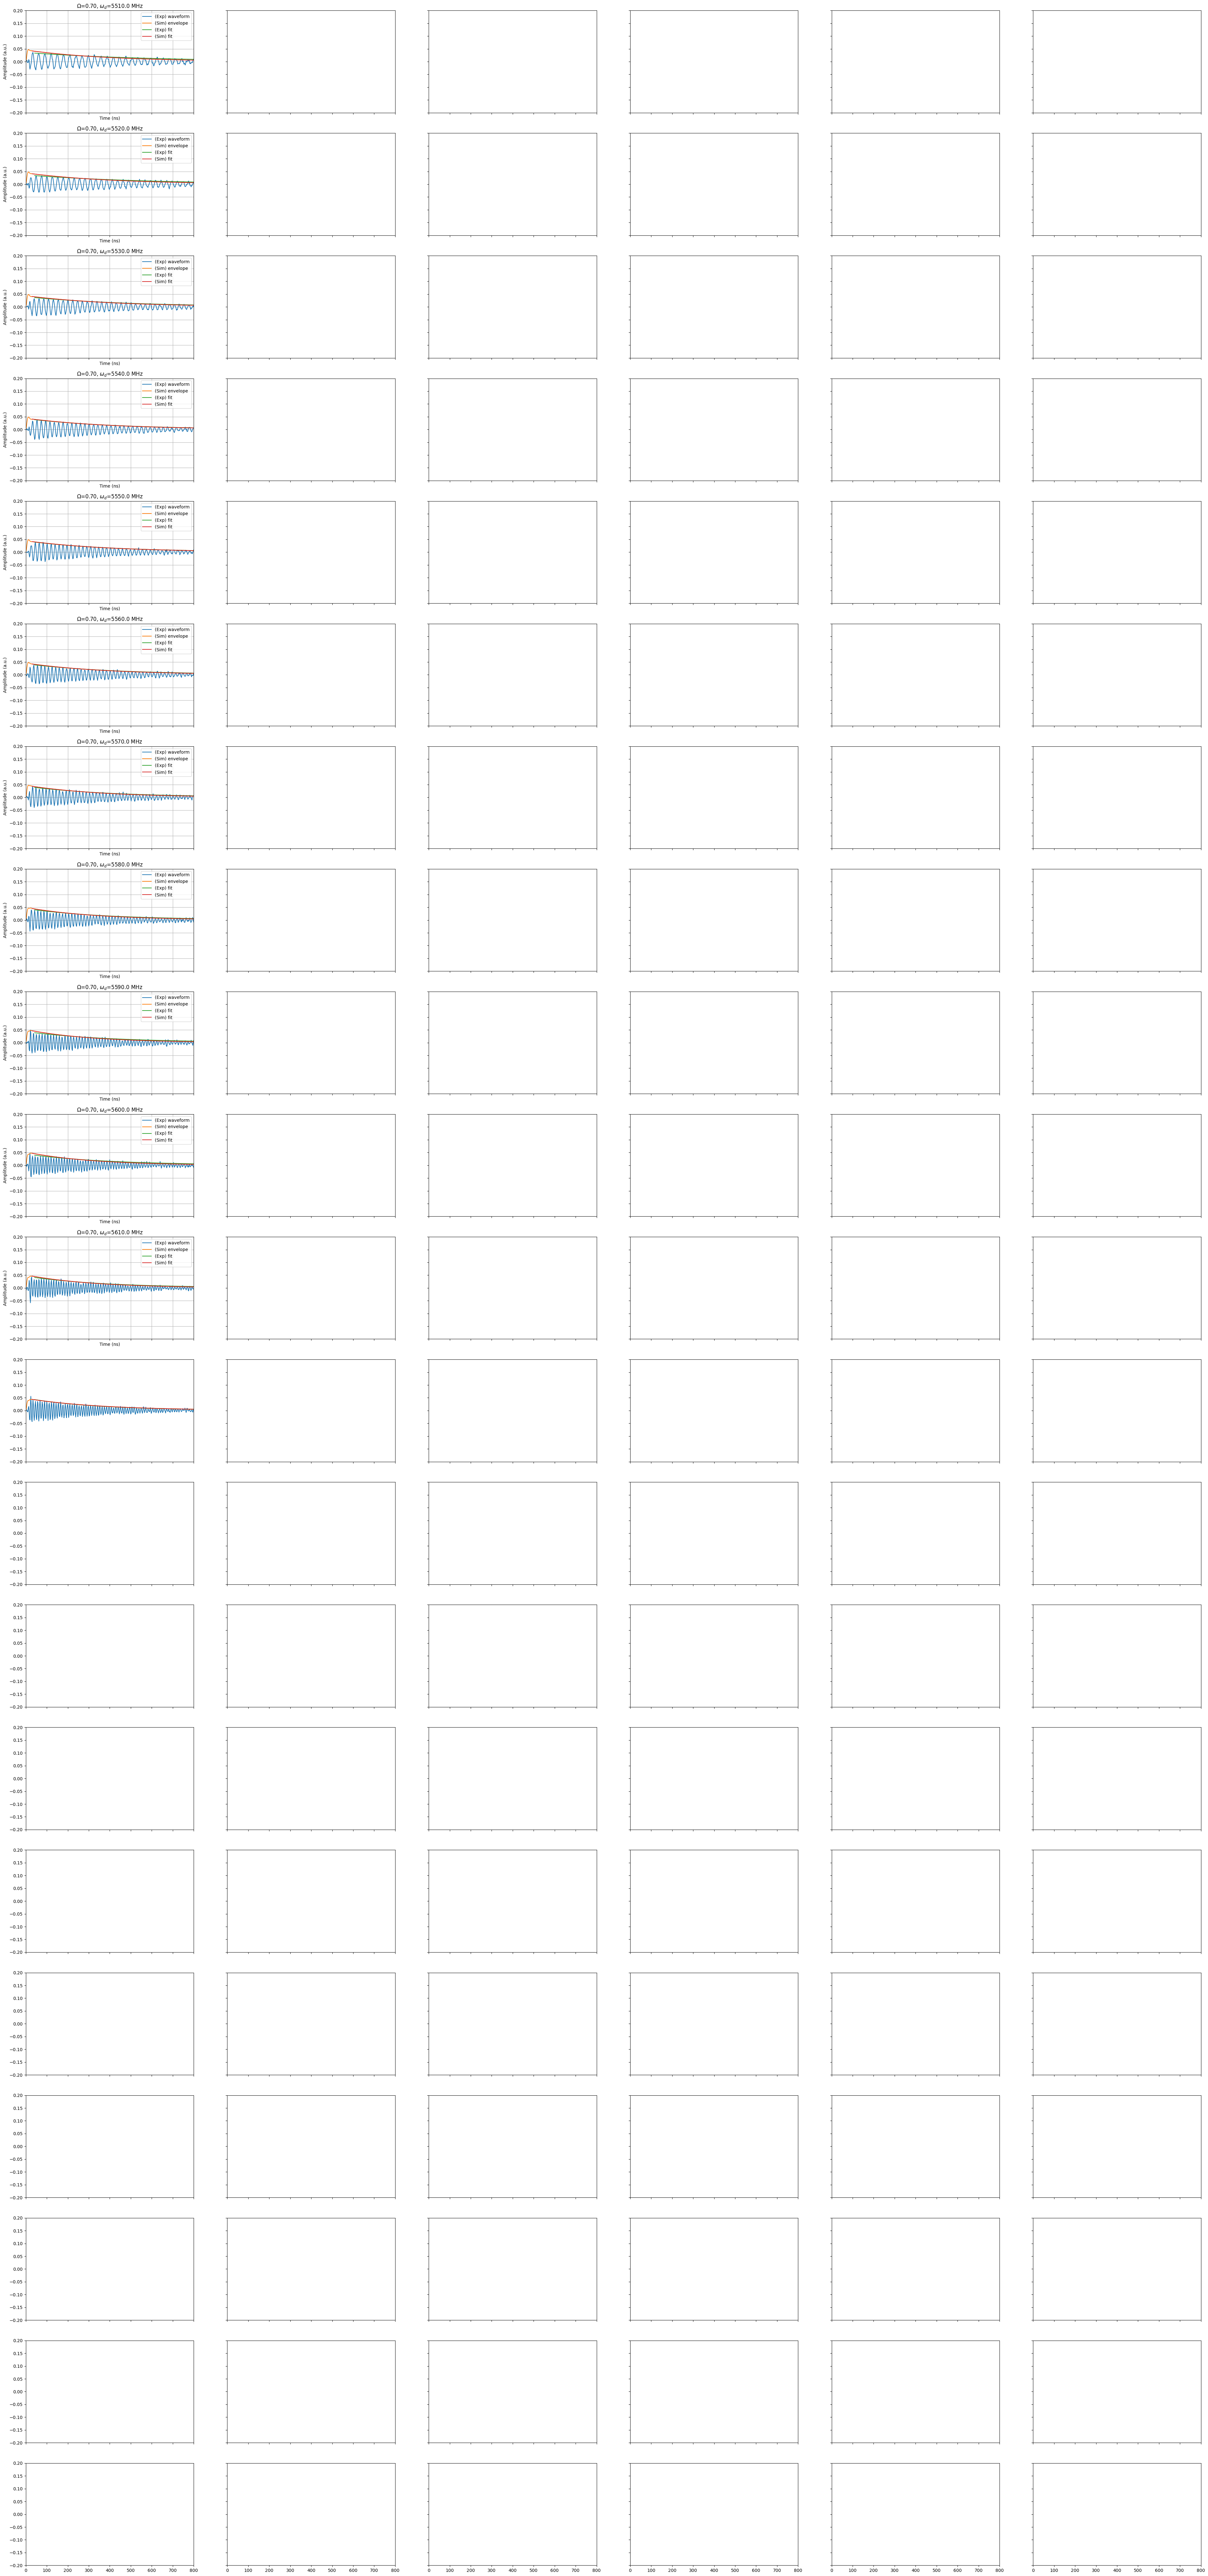

In [29]:
from lmfit import Model

num_amp_idx = len(tmfs_by_omega)
fig, axes = plt.subplots(len(tmfs_by_omega[0]), num_amp_idx, 
                         figsize=(8 * num_amp_idx, 5 * len(tmfs_by_omega[0])),
                         sharex=True, sharey=True)

if len(tmfs_by_omega[0]) == 1:
    axes = [axes]
if num_amp_idx == 1:
    axes = [[ax] for ax in axes] 

for amp_idx in range(num_amp_idx):
    time, fit_time, waveforms, envelopes, fits = fitted_waveforms[amp_idx]

    fit_results = []
    for idx, tmf in enumerate(tmfs_by_omega[amp_idx]):
        def model_function(x, amp):
            return envelopes[idx][0:379] * amp
        model = Model(model_function)
        params = model.make_params(amp=3e2)
        res = model.fit(tmf[22::], params, x=t[22::] * 1e3)
        fit_results.append(res.params['amp'].value)

        ax = axes[idx][amp_idx]
        ax.plot(time, waveforms[idx] * fit_results[idx], label='(Exp) waveform')
        ax.plot(t * 1e3, tmfs_by_omega[amp_idx][idx], label='(Sim) envelope')
        ax.plot(time[21::], fits[idx] * fit_results[idx], label='(Exp) fit')
        ax.plot(t[skip_data:] * 1e3, fits_by_omega[amp_idx][idx], label='(Sim) fit')
        
        ax.set_title(f"$\Omega$={Omegas[amp_idx]:.2f}, "
                     f"$\omega_d$={omegadrive_f0g1_dict[Omegas[amp_idx]][idx]/(2*np.pi):.1f} MHz")
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Amplitude (a.u.)")
        ax.set_xlim(0, 800)
        ax.set_ylim(-0.2, 0.2)
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.show()


In [51]:

skip_data = 15
fits_by_omega_J = []
tmfs_by_omega_J = []
tmf_times_by_omega_J = []
decay_rates_by_omega_J = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_J):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        # ax.plot(t, tmf, label=f"Omega_idx={omega_idx}, Detun_idx={detun_idx}")
        # ax.plot(t[skip_data:], fit_result.best_fit, label="Fit")
        # ax.set_title(f"Omega={Omegas[omega_idx]:.1f}, omega_d={omegadrive_f0g1_dict[Omegas[omega_idx]][detun_idx]/(2*np.pi):.1f} MHz")
        # ax.set_xlabel("Time")
        # ax.set_ylabel("Amplitude")
        # ax.legend()
        # ax.grid()

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_J.append(fits_per_omega)
    tmfs_by_omega_J.append(tmfs_per_omega)
    tmf_times_by_omega_J.append(tmf_times_per_omega)
    decay_rates_by_omega_J.append(decay_rates_per_omega)

In [52]:
skip_data = 15
fits_by_omega_J20 = []
tmfs_by_omega_J20 = []
tmf_times_by_omega_J20 = []
decay_rates_by_omega_J20 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_J20):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_J20.append(fits_per_omega)
    tmfs_by_omega_J20.append(tmfs_per_omega)
    tmf_times_by_omega_J20.append(tmf_times_per_omega)
    decay_rates_by_omega_J20.append(decay_rates_per_omega)

In [53]:
skip_data = 15
fits_by_omega_g20 = []
tmfs_by_omega_g20 = []
tmf_times_by_omega_g20 = []
decay_rates_by_omega_g20 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_g20):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_g20.append(fits_per_omega)
    tmfs_by_omega_g20.append(tmfs_per_omega)
    tmf_times_by_omega_g20.append(tmf_times_per_omega)
    decay_rates_by_omega_g20.append(decay_rates_per_omega)

In [54]:
skip_data = 15
fits_by_omega_gmi20 = []
tmfs_by_omega_gmi20 = []
tmf_times_by_omega_gmi20 = []
decay_rates_by_omega_gmi20 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_gmi20):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_gmi20.append(fits_per_omega)
    tmfs_by_omega_gmi20.append(tmfs_per_omega)
    tmf_times_by_omega_gmi20.append(tmf_times_per_omega)
    decay_rates_by_omega_gmi20.append(decay_rates_per_omega)

In [55]:
skip_data = 15
fits_by_omega_kappa20 = []
tmfs_by_omega_kappa20 = []
tmf_times_by_omega_kappa20 = []
decay_rates_by_omega_kappa20 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_kappa20):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_kappa20.append(fits_per_omega)
    tmfs_by_omega_kappa20.append(tmfs_per_omega)
    tmf_times_by_omega_kappa20.append(tmf_times_per_omega)
    decay_rates_by_omega_kappa20.append(decay_rates_per_omega)

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\G'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\2278578416.py:33: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\2278578416.py:34: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_3100\2278578416.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))


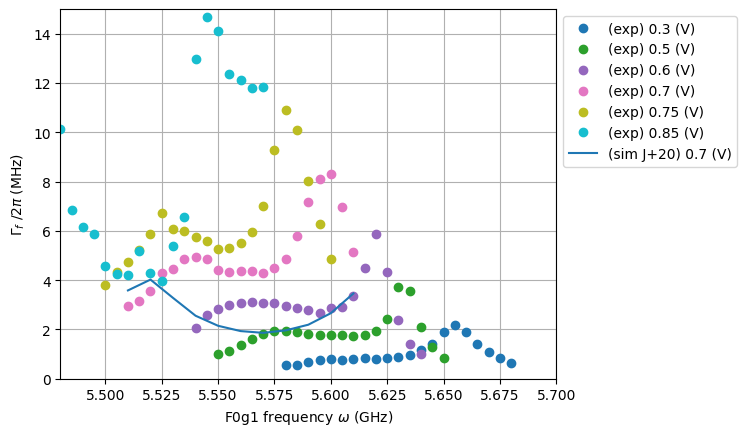

In [23]:
import matplotlib.cm as cm


# omegadrive_f0g1_dict = {
#     0.3: np.array(np.linspace(5.58, 5.68, 21)) *1e3* 2 * np.pi,
#     0.5: np.array(np.linspace(5.55, 5.65, 21))*1e3*  2 * np.pi,
#     0.6: np.array(np.linspace(5.54, 5.64, 21))*1e3*  2 * np.pi,
#     0.7: np.array(np.linspace(5.51, 5.61, 21)) *1e3* 2 * np.pi,
#     0.75: np.array(np.linspace(5.5, 5.6, 21))*1e3*  2 * np.pi,
#     0.85: np.array(np.linspace(5.48, 5.58, 21))*1e3*  2 * np.pi,
# }
Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
cmap = cm.get_cmap("tab10", len(Omegas))
# for i in range(len(fogi_freqs)):
#     color = cmap(i)
#     plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
#     plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega[i]) * 2,
#               '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
for i in range(len(fogi_freqs)):
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    # plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gmi20[i]) * 2,
    #           '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.plot(np.array(np.array(np.linspace(5.51, 5.61, 11)) *1e3* 2 * np.pi/(2*np.pi))*1e-3, np.array(decay_rates_by_omega[0]) * 2,
              '-', label=f"(sim J+20) {Omegas[3]} (V)")
# # plt.plot(np.array(np.array(np.linspace(5.51, 5.61, 11)) *1e3* 2 * np.pi/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gmi20[0]) * 2,
# #               '-', label=f"(sim g-20) {Omegas[3]} (V)")
# plt.plot(np.array(np.array(np.linspace(5.51, 5.61, 11)) *1e3* 2 * np.pi/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_kappa20[0]) * 2,
#               '-', label=f"(sim kappa+20) {Omegas[3]} (V)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()

In [62]:
def g_sweep(gqcav, file_name):
    Nqu=4;
    Nres=3;
    Nfil=3;
    ## define qubit 
    omegaq=2*np.pi*7699;
    aharmon=-2*np.pi*372;
    chi=-2*np.pi*3.05;
    bqub=destroy(Nqu);
    bqubd=create(Nqu);
    ## define resonator
    omegares=2*np.pi*9375;
    delta=omegaq - omegares;
    Jcavfil=2*np.pi*46;
    cavobj=basis(Nres);
    acav=destroy(Nres);
    acavd=create(Nres);
    ## define filter
    omegafil=2*np.pi*9391;
    kappa=2*np.pi*95
    filterobj=basis(Nfil);
    fcav=destroy(Nfil);
    fcavd=create(Nfil);
    ## qubit-resonator coupling strength
    # gqcav=(chi*delta*(delta+aharmon)/aharmon)**0.5-20*2*np.pi;
    omega_rotate=0#2*np.pi*6000

    zeromatrixxtmp=np.zeros([Nqu,Nqu])
    zeromatrixxtmp[0,1]=1
    gedecayop=Qobj(zeromatrixxtmp)

    zeromatrixxtmp=np.zeros([Nqu,Nqu])
    zeromatrixxtmp[1,2]=1
    efdecayop=Qobj(zeromatrixxtmp)

    zeromatrixxtmp=np.zeros([Nqu,Nqu])
    zeromatrixxtmp[0,0]=-1
    zeromatrixxtmp[1,1]=1
    gedechoop=Qobj(zeromatrixxtmp)

    T1geapprox=22
    T1efapprox=12
    T2geapprox=8
    gammaT1ge=1/T1geapprox #
    gammaT1ef=1/T1efapprox #
    gammaTphige=(1/T2geapprox-1/T1geapprox/2)/2
    ##### 
    c_ops_fil=[];
    c_ops_fil.append(np.sqrt(kappa)*tensor(qeye(Nqu),qeye(Nres),fcav))
    # c_ops_fil.append(np.sqrt(gammaT1ge)*tensor(gedecayop,qeye(Nres),qeye(Nfil)))
    # c_ops_fil.append(np.sqrt(gammaT1ef)*tensor(efdecayop,qeye(Nres),qeye(Nfil)))
    # c_ops_fil.append(np.sqrt(gammaTphige)*tensor(gedechoop,qeye(Nres),qeye(Nfil)))

    H0_fil=(omegaq-omega_rotate)*tensor(bqubd*bqub,qeye(Nres),qeye(Nfil))+aharmon/2*tensor(bqubd*bqubd*bqub*bqub,qeye(Nres),qeye(Nfil))\
    +(omegares-omega_rotate)*tensor(qeye(Nqu),acavd*acav,qeye(Nfil))+gqcav*(tensor(bqub,acavd,qeye(Nfil))+tensor(bqubd,acav,qeye(Nfil)))\
    +(omegafil-omega_rotate)*tensor(qeye(Nqu),qeye(Nres),fcavd*fcav)+Jcavfil*(tensor(qeye(Nqu),acavd,fcav)+tensor(qeye(Nqu),acav,fcavd))

    def H1_coeff_sq_f0g1_pulse_ani(t, args):
        return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(-1j*omega_rotate*t)

    def H1_coeff_sq_f0g1_pulse_crea(t, args):
        return args['Omegagf']*np.sin(args['omegadrive_f0g1']*t)*np.exp(1j*omega_rotate*t)

    H1_anni_fil= tensor(bqub,qeye(Nres),qeye(Nfil))
    H1_crea_fil= tensor(bqubd,qeye(Nres),qeye(Nfil))

    H_f0g1_fil = [ H0_fil,
                [H1_anni_fil, H1_coeff_sq_f0g1_pulse_ani],
                [H1_crea_fil, H1_coeff_sq_f0g1_pulse_crea]
                ]

    eigsystem_fil=H0_fil.eigenstates()
    f0_fil=tensor(basis(Nqu,2),cavobj,filterobj);
    e0_fil=tensor(basis(Nqu,1),cavobj,filterobj);
    g0_fil=tensor(basis(Nqu),cavobj,filterobj);

    overlaplistf0_fil=[fidelity(f0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
    overlapliste0_fil=[fidelity(e0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]
    overlaplistg0_fil=[fidelity(g0_fil,eigsystem_fil[1][cc]) for cc in range(len(eigsystem_fil[0]))]

    maxindexf0_fil=overlaplistf0_fil.index(max(overlaplistf0_fil))
    maxindexe0_fil=overlapliste0_fil.index(max(overlapliste0_fil))
    maxindexg0_fil=overlaplistg0_fil.index(max(overlaplistg0_fil))

    initialstatef0_fil=eigsystem_fil[1][maxindexf0_fil]
    initialstatee0_fil=eigsystem_fil[1][maxindexe0_fil]
    initialstateg0_fil=g0_fil

    Tf=0.8
    t=np.linspace(0,Tf, 401)
    testinitialstate_fil=(initialstatef0_fil+initialstateg0_fil).unit()

    gstate_fil=tensor(ket2dm(basis(Nqu)),qeye(Nres),qeye(Nfil))
    estate_fil=tensor(ket2dm(basis(Nqu,1)),qeye(Nres),qeye(Nfil))
    fstate_fil=tensor(ket2dm(basis(Nqu,2)),qeye(Nres),qeye(Nfil))
    hstate_fil=tensor(ket2dm(basis(Nqu,3)),qeye(Nres),qeye(Nfil))

    omegadrive_f0g1_dict = {
        # 0.3: np.array(np.linspace(5.58, 5.68, 11)) *1e3* 2 * np.pi,
        0.5: np.array(np.linspace(5.55, 5.65, 11))*1e3*  2 * np.pi,
        # 0.6: np.array(np.linspace(5.54, 5.64, 11))*1e3*  2 * np.pi,
        0.7: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi,
        # 0.75: np.array(np.linspace(5.5, 5.6, 11))*1e3*  2 * np.pi,
        # 0.85: np.array(np.linspace(5.48, 5.58, 11))*1e3*  2 * np.pi,
        1.0: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi,
        1.5: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi
    }
    # Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])

    results2 = []
    for Omega in Omegas:
        output_decay_f0g1_fils = []
        drive_freqs = omegadrive_f0g1_dict[Omega]  
        for drive_freq in drive_freqs:
            args = {
                'Omegagf': fitted_c*1e-6*Omega,
                'omegadrive_f0g1': drive_freq
            }

            output_decay_f0g1_fil = mesolve(H_f0g1_fil,testinitialstate_fil, t, c_ops_fil,e_ops=[gstate_fil,estate_fil,fstate_fil,hstate_fil,tensor(qeye(Nqu),qeye(Nres),fcav)], args=args, progress_bar=True)
            output_decay_f0g1_fils.append(output_decay_f0g1_fil)
            print(file_name)
            print(f'Omegagf={Omega}, omegadrive_f0g1={drive_freq/(2*np.pi)} finished')
        results2.append(output_decay_f0g1_fils)

    qutip.qsave(results2, file_name)

In [63]:
g_sweep((chi*delta*(delta+aharmon)/aharmon)**0.5-10*2*np.pi, "250128_0_g-10")
g_sweep((chi*delta*(delta+aharmon)/aharmon)**0.5-5*2*np.pi, "250128_0_g-5")
g_sweep((chi*delta*(delta+aharmon)/aharmon)**0.5+0*2*np.pi, "250128_0_g")
g_sweep((chi*delta*(delta+aharmon)/aharmon)**0.5+5*2*np.pi, "250128_0_g+5")
g_sweep((chi*delta*(delta+aharmon)/aharmon)**0.5+10*2*np.pi, "250128_0_g+10")

c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   9.85s. Est. time left: 00:00:01:28
20.0%. Run time:  19.27s. Est. time left: 00:00:01:17
30.0%. Run time:  29.26s. Est. time left: 00:00:01:08
40.0%. Run time:  38.68s. Est. time left: 00:00:00:58
50.0%. Run time:  48.14s. Est. time left: 00:00:00:48
60.0%. Run time:  57.57s. Est. time left: 00:00:00:38
70.0%. Run time:  67.38s. Est. time left: 00:00:00:28
80.0%. Run time:  77.06s. Est. time left: 00:00:00:19
90.0%. Run time:  86.70s. Est. time left: 00:00:00:09
100.0%. Run time:  96.33s. Est. time left: 00:00:00:00
Total run time:  96.33s
250128_0_g-10
Omegagf=0.5, omegadrive_f0g1=5550.0 finished
10.0%. Run time:   9.66s. Est. time left: 00:00:01:26
20.0%. Run time:  19.32s. Est. time left: 00:00:01:17
30.0%. Run time:  28.90s. Est. time left: 00:00:01:07
40.0%. Run time:  38.49s. Est. time left: 00:00:00:57
50.0%. Run time:  48.18s. Est. time left: 00:00:00:48
60.0%. Run time:  58.03s. Est. time left: 00:00:00:38
70.0%. Run time:  67.64s. Est. time left: 00:00:00:2

In [20]:
result_gmi10 = qload("250128_0_g-10")
result_gmi5 = qload("250128_0_g-5")
result_g = qload("250128_0_g")
result_gpl5 = qload("250128_0_g+5")
result_gpl10 = qload("250128_0_g+10")

In [21]:
skip_data = 15
fits_by_omega_gmi10 = []
tmfs_by_omega_gmi10 = []
tmf_times_by_omega_gmi10 = []
decay_rates_by_omega_gmi10 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_gmi10):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_gmi10.append(fits_per_omega)
    tmfs_by_omega_gmi10.append(tmfs_per_omega)
    tmf_times_by_omega_gmi10.append(tmf_times_per_omega)
    decay_rates_by_omega_gmi10.append(decay_rates_per_omega)

In [22]:
skip_data = 15
fits_by_omega_gmi5 = []
tmfs_by_omega_gmi5 = []
tmf_times_by_omega_gmi5 = []
decay_rates_by_omega_gmi5 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_gmi5):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_gmi5.append(fits_per_omega)
    tmfs_by_omega_gmi5.append(tmfs_per_omega)
    tmf_times_by_omega_gmi5.append(tmf_times_per_omega)
    decay_rates_by_omega_gmi5.append(decay_rates_per_omega)

In [23]:
skip_data = 15
fits_by_omega_g = []
tmfs_by_omega_g = []
tmf_times_by_omega_g = []
decay_rates_by_omega_g = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_g):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_g.append(fits_per_omega)
    tmfs_by_omega_g.append(tmfs_per_omega)
    tmf_times_by_omega_g.append(tmf_times_per_omega)
    decay_rates_by_omega_g.append(decay_rates_per_omega)

In [24]:
skip_data = 15
fits_by_omega_gpl5 = []
tmfs_by_omega_gpl5 = []
tmf_times_by_omega_gpl5 = []
decay_rates_by_omega_gpl5 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_gpl5):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_gpl5.append(fits_per_omega)
    tmfs_by_omega_gpl5.append(tmfs_per_omega)
    tmf_times_by_omega_gpl5.append(tmf_times_per_omega)
    decay_rates_by_omega_gpl5.append(decay_rates_per_omega)

In [25]:
skip_data = 15
fits_by_omega_gpl10 = []
tmfs_by_omega_gpl10 = []
tmf_times_by_omega_gpl10 = []
decay_rates_by_omega_gpl10 = []
# `results` : results[Omega_index][detun_index]
for omega_idx, omega_results in enumerate(result_gpl10):
    fits_per_omega = []
    tmfs_per_omega = []
    tmf_times_per_omega = [] 
    decay_rates_per_omega = []
    for detun_idx, output_decay_f0g1_fil in enumerate(omega_results):
        # fig, ax = plt.subplots(figsize=(5,3))

        tmf_time = output_decay_f0g1_fil.expect[-1]
        tmf = np.abs(tmf_time)
        fit_result = decay_fit(tmf[skip_data:], t[skip_data:])

        fits_per_omega.append(fit_result.best_fit)
        tmfs_per_omega.append(tmf)
        tmf_times_per_omega.append(tmf_time)
        decay_rates_per_omega.append(fit_result.params.valuesdict()["gamma"] /2/np.pi)

        # plt.show()
    fits_by_omega_gpl10.append(fits_per_omega)
    tmfs_by_omega_gpl10.append(tmfs_per_omega)
    tmf_times_by_omega_gpl10.append(tmf_times_per_omega)
    decay_rates_by_omega_gpl10.append(decay_rates_per_omega)

<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\G'
<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\3069333754.py:26: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\3069333754.py:27: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\3069333754.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\3069333754.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 an

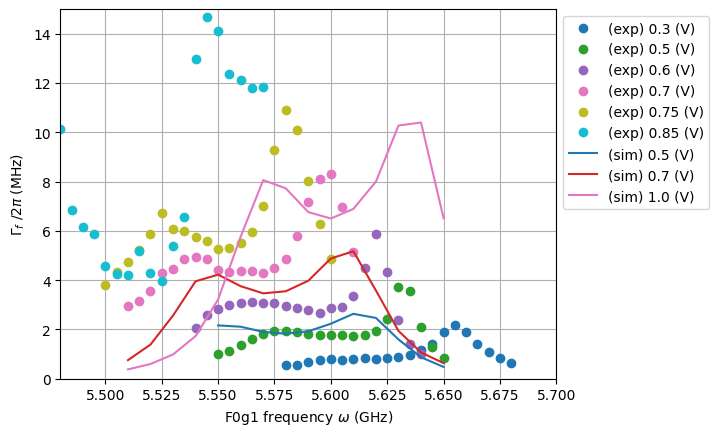

In [43]:
import matplotlib.cm as cm

omegadrive_f0g1_dict = {
        0.5: np.array(np.linspace(5.55, 5.65, 11))*1e3*  2 * np.pi,
        0.7: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi,
        1.0: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi,
        1.5: np.array(np.linspace(5.51, 5.65, 15)) *1e3* 2 * np.pi
    }

for i in range(len(fogi_freqs)):
    Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)

    
for i in range(3):
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    # plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gmi10[i]) * 2,
              '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1062234843.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1062234843.py:18: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1062234843.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1062234843.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and

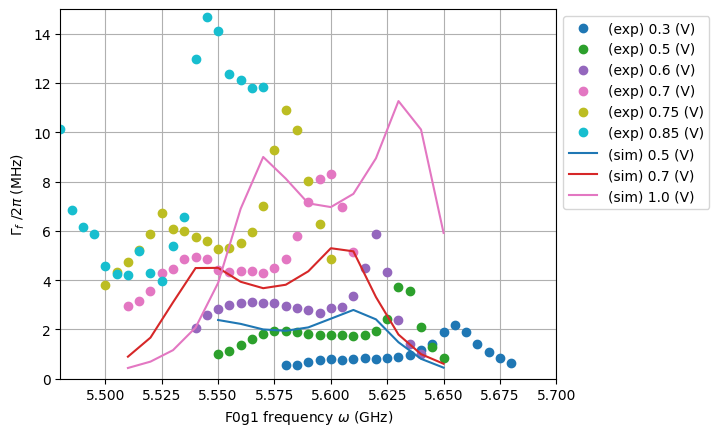

In [44]:
for i in range(len(fogi_freqs)):
    Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)

    
for i in range(3):
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    # plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gmi5[i]) * 2,
              '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2581271915.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2581271915.py:18: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2581271915.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2581271915.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and

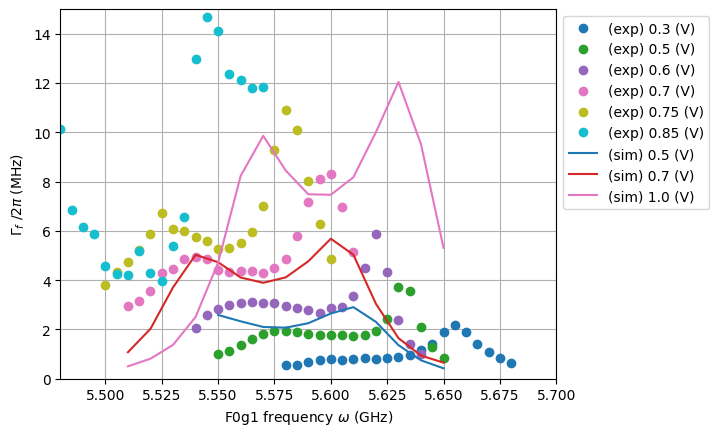

In [45]:
for i in range(len(fogi_freqs)):
    Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)

    
for i in range(3):
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    # plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_g[i]) * 2,
              '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1273713570.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1273713570.py:18: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1273713570.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\1273713570.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and

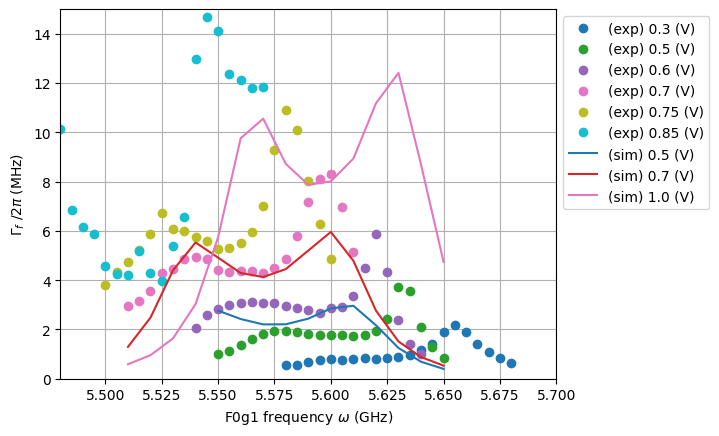

In [46]:
for i in range(len(fogi_freqs)):
    Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)

    
for i in range(3):
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    # plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gpl5[i]) * 2,
              '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2542508339.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('F0g1 frequency $\omega$ (GHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2542508339.py:18: SyntaxWarning: invalid escape sequence '\G'
  plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2542508339.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(Omegas))
C:\Users\qipe\AppData\Local\Temp\ipykernel_22452\2542508339.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and

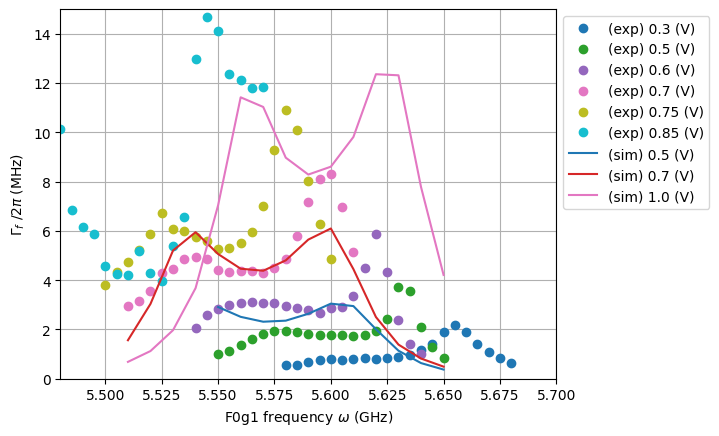

In [47]:
for i in range(len(fogi_freqs)):
    Omegas = np.array([0.3, 0.5, 0.6, 0.7, 0.75, 0.85])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)

    
for i in range(3):
    Omegas = np.array([0.5, 0.7, 1.0, 1.5])
    cmap = cm.get_cmap("tab10", len(Omegas))
    color = cmap(i)
    # plt.plot(fogi_freqs[i], decay_rates[i], 'o', label=f"(exp) {Omegas[i]} (V)", color=color)
    plt.plot(np.array(omegadrive_f0g1_dict[Omegas[i]]/(2*np.pi))*1e-3, np.array(decay_rates_by_omega_gpl10[i]) * 2,
              '-', label=f"(sim) {Omegas[i]} (V)", color=color)
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('F0g1 frequency $\omega$ (GHz)')
plt.ylabel('$\Gamma_f $ /2$\pi$ (MHz)')
plt.xlim(5.48, 5.7)
plt.ylim(0, 15)
plt.grid()